In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [238]:
df = pd.read_csv("C:/Users/Anastasia_Golubova/Yandex.Disk/OTUS_Networks/hw_clustering/german_credit_data.csv",index_col=0)

In [239]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,40,male,3,own,little,little,3857,30,car
997,38,male,2,own,little,NaN,804,12,radio/TV
998,23,male,2,free,little,little,1845,45,radio/TV


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB


### EDA

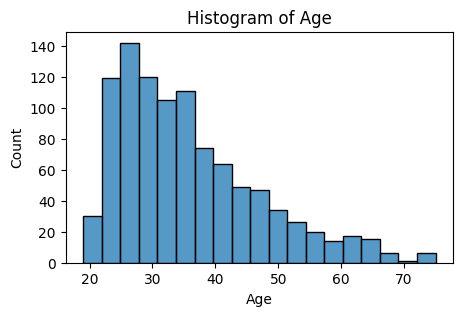

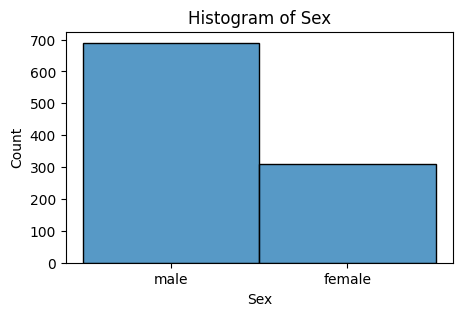

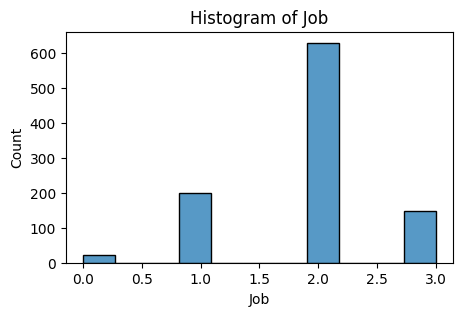

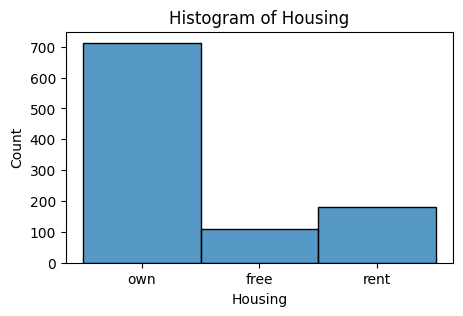

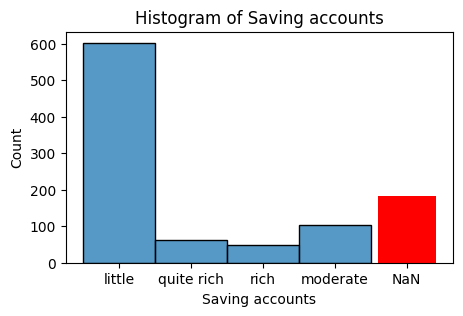

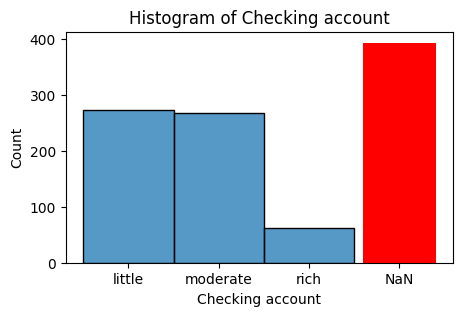

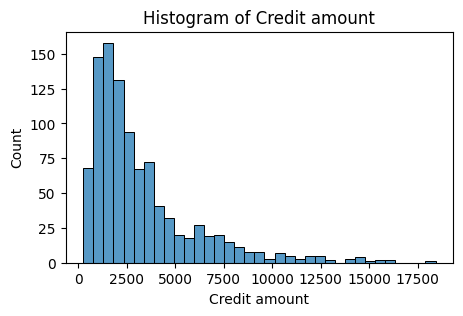

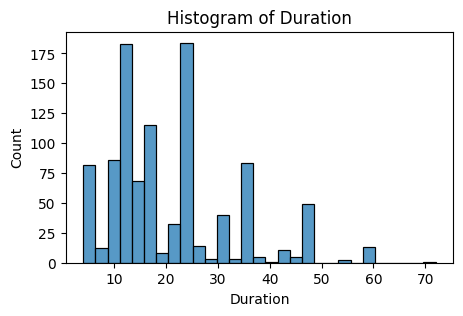

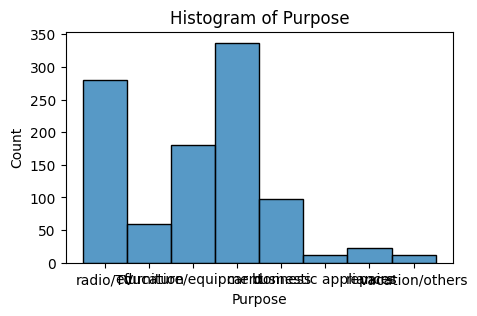

In [241]:
for col in df.columns:
    plt.figure(figsize=(5, 3))

    values = df[col]
    n_nan = values.isna().sum()

    sns.histplot(values.dropna())

    if n_nan > 0:
        plt.bar(["NaN"], [n_nan], color="red")

    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [242]:
#check missing values
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [243]:
### удалим cheking account потому что там много пропусков
df = df.drop(columns='Checking account')

In [244]:
### удалим образцы с пропущенным значением Saving account
df = df.dropna(subset='Saving accounts')

In [245]:
df.shape

(817, 8)

In [246]:
numeric = df.select_dtypes(include='number')
numeric.describe()

,Age,Job,Credit amount,Duration
count,817.000000,817.000000,817.000000,817.00000
mean,35.127295,1.894737,3128.990208,20.49694
std,11.348251,0.653935,2731.688353,11.84149
min,19.000000,0.000000,250.000000,4.00000
25%,26.000000,2.000000,1355.000000,12.00000
50%,32.000000,2.000000,2241.000000,18.00000
75%,41.000000,2.000000,3850.000000,24.00000
max,75.000000,3.000000,18424.000000,72.00000


In [247]:
### преобразуем категориальные признаки
## все, кроме Saving account можно преобразовать с помощью one hot encoding, Saving account - ordinal encoding
data_cat = df.select_dtypes(include='object')
data_cat = data_cat.drop(columns='Saving accounts')
data_cat_one = pd.get_dummies(data_cat).astype(int)

enc = OrdinalEncoder(
    categories=[["little", "moderate", "rich",'quite rich']])
df['Saving accounts encoded'] = enc.fit_transform(df[["Saving accounts"]])
df_clus = df.drop(columns=data_cat.columns)
df_clus = df_clus.drop(columns=['Saving accounts'])
df_clus = pd.concat([df_clus,data_cat_one],axis=1)

In [248]:
df_clus

,Age,Job,Credit amount,Duration,Saving accounts encoded,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
1,22,2,5951,48,0.0,1,0,0,1,0,0,0,0,0,0,1,0,0
2,49,1,2096,12,0.0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,45,2,7882,42,0.0,0,1,1,0,0,0,0,0,0,1,0,0,0
4,53,2,4870,24,0.0,0,1,1,0,0,0,1,0,0,0,0,0,0
6,53,2,2835,24,3.0,0,1,0,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,0.0,1,0,0,1,0,0,0,0,0,1,0,0,0
996,40,3,3857,30,0.0,0,1,0,1,0,0,1,0,0,0,0,0,0
997,38,2,804,12,0.0,0,1,0,1,0,0,0,0,0,0,1,0,0
998,23,2,1845,45,0.0,0,1,1,0,0,0,0,0,0,0,1,0,0


<Axes: >

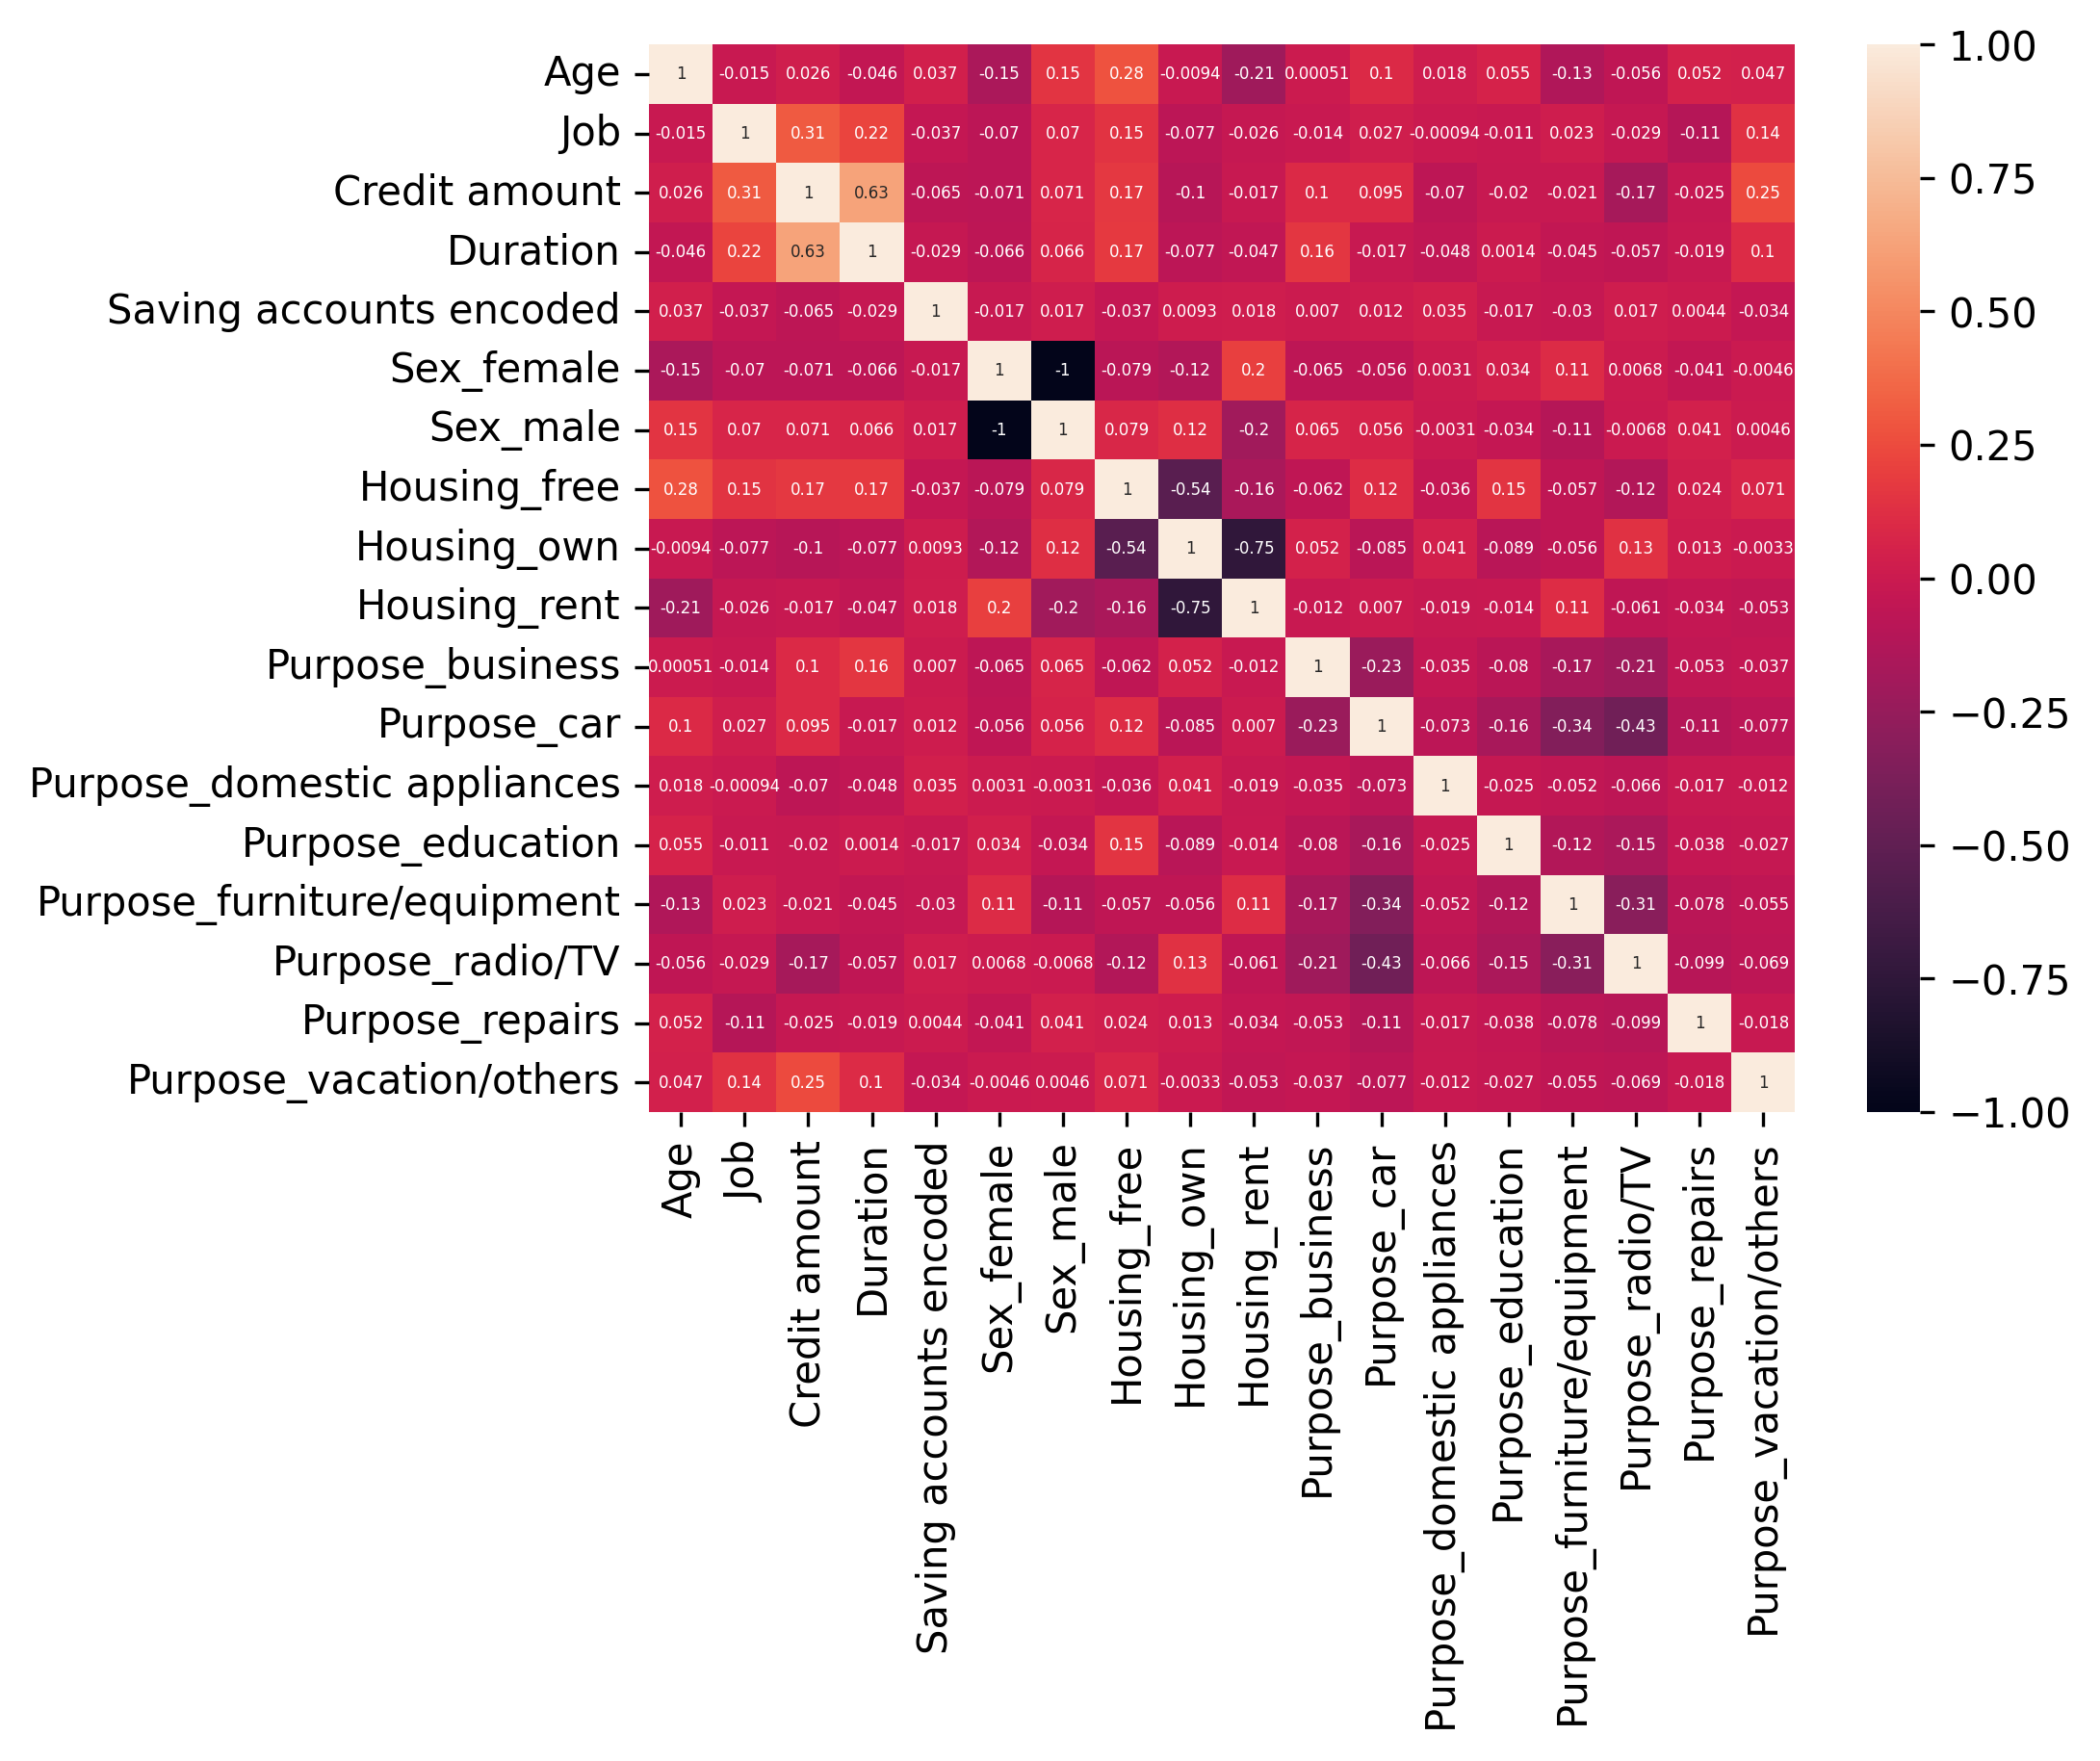

In [249]:
plt.figure(dpi=300)
cor_mat = df_clus.corr()
sns.heatmap(cor_mat,annot=True,annot_kws={"size": 4})

#### Ожидаемо,хорошо коррелируют размер кредита и срок между собой, а также с уровнем квалификации кредиторов 

### масштабируем числовые признаки, а также категориальные с ordinal encoding, т.к. при кластеризации признаки с большими числовыми значениями будут оттягивать на себя остальные точки и будут доминировать в расстоянии

In [250]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    df[['Age','Job','Credit amount','Duration','Saving accounts encoded']]
)

df_scaled = pd.DataFrame(
    scaled,
    index=df.index
)
df_scaled.columns = ['Age','Job','Credit amount','Duration','Saving accounts encoded']
df_label = df_clus.drop(columns=['Age','Job','Credit amount','Duration','Saving accounts encoded'])
df_km = pd.concat([df_scaled,df_label],axis=1)

#### kmeans

In [251]:
from sklearn.cluster import KMeans

def elbow_kmeans(X, k_range=range(1, 11), random_state=42):
    results = []

    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init="auto"
        )
        kmeans.fit(X)
        results.append({
            "k": k,
            "inertia": kmeans.inertia_
        })

    results_df = pd.DataFrame(results)

    plt.figure(figsize=(6, 4))
    plt.plot(results_df["k"], results_df["inertia"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for KMeans")
    plt.xticks(results_df["k"])
    plt.grid(True)
    plt.show()

    return results_df

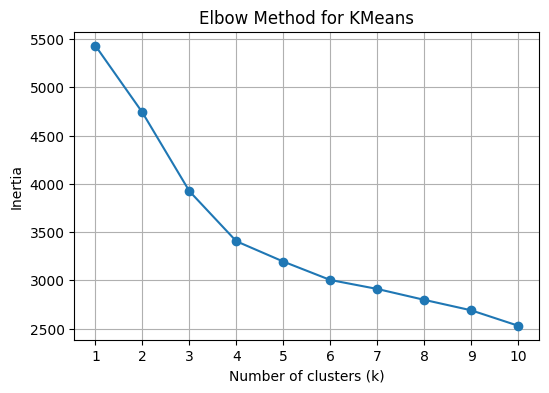

,k,inertia
0,1,5431.066095
1,2,4739.548854
2,3,3923.960011
3,4,3404.815514
4,5,3194.255087
5,6,3003.418821
6,7,2910.308075
7,8,2797.546481
8,9,2689.058304
9,10,2529.266601


In [252]:
elbow_df = elbow_kmeans(df_km, k_range=range(1, 11))
elbow_df

In [253]:
from sklearn.metrics import silhouette_score
def plot_silhouette_kmeans(X, k_range=range(2, 11), random_state=42):

    scores = []

    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init="auto"
        )

        labels = kmeans.fit_predict(X)

        score = silhouette_score(X, labels)
        scores.append(score)

    plt.figure(figsize=(6, 4))
    plt.plot(list(k_range), scores, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette Method for KMeans")
    plt.grid(True)
    plt.show()

    return scores

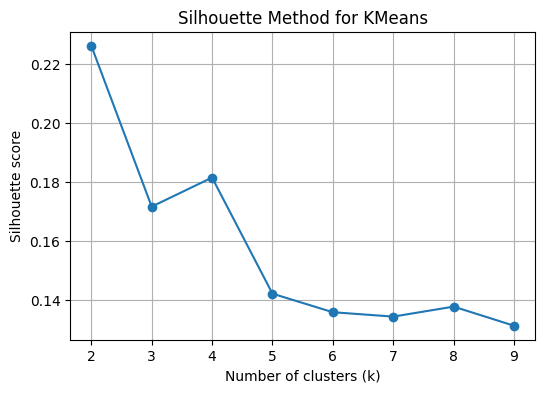

[np.float64(0.22607749601009167),
 np.float64(0.17161917846657726),
 np.float64(0.1814584415497601),
 np.float64(0.14216796601205933),
 np.float64(0.1358918195253713),
 np.float64(0.13440612119364698),
 np.float64(0.13778743836513854),
 np.float64(0.13132178406105677)]

In [254]:
plot_silhouette_kmeans(df_km, range(2, 10))

In [255]:
### по результатам двух методом выбираем число калстеров = 4
kmeans = KMeans(n_clusters=4)
df_km['Cluster'] = kmeans.fit_predict(df_km)
uniq = df_km.sort_values(by='Cluster')
clusters = uniq

df_sorted = clusters.sort_values('Cluster')
df_heatmap = df_sorted.drop('Cluster', axis=1)
cmap = sns.diverging_palette(240,10, s=300,l=40,n=9, as_cmap=True)
plt.figure(figsize=(100, 100))
sns.heatmap(df_heatmap, center=0,cmap=cmap,cbar_kws={'shrink': 0.1, 'aspect':8, 'ticks': np.arange(-1.5, 1.8, 0.5)},
            cbar=True,linewidths=0.01, 
    linecolor='black')
plt.xticks(fontsize=40,rotation=90);
plt.yticks(fontsize=8);

In [256]:
X = df_km.drop(columns='Cluster')

In [257]:
### визуализируем РСА

from sklearn.decomposition import PCA

def plot_pca_clusters(X, labels, figsize=(6, 5)):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)

    plot_df = pd.DataFrame({
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "Cluster": labels
    })

    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        c=plot_df["Cluster"],
        s=40
    )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA of clusters")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()

    return plot_df

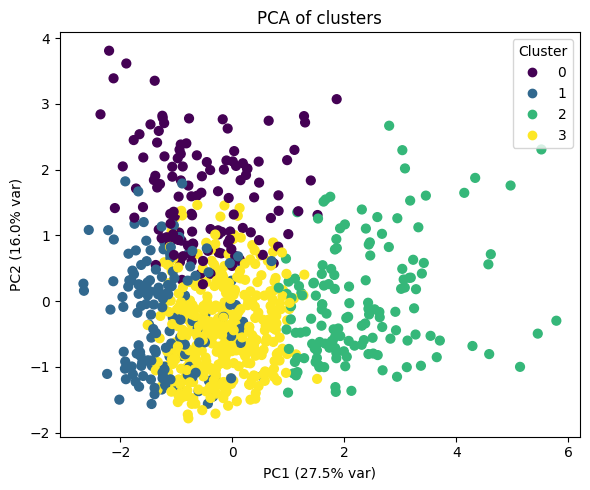

In [258]:
pca_df = plot_pca_clusters(X, df_km["Cluster"])

In [259]:
from sklearn.manifold import TSNE

def plot_tsne_clusters(X, labels, perplexity=30, figsize=(6, 5)):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    coords = tsne.fit_transform(X)

    plot_df = pd.DataFrame({
        "tSNE1": coords[:, 0],
        "tSNE2": coords[:, 1],
        "Cluster": labels
    })

    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        plot_df["tSNE1"],
        plot_df["tSNE2"],
        c=plot_df["Cluster"],
        s=40
    )
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.title("t-SNE of clusters")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()

    return plot_df

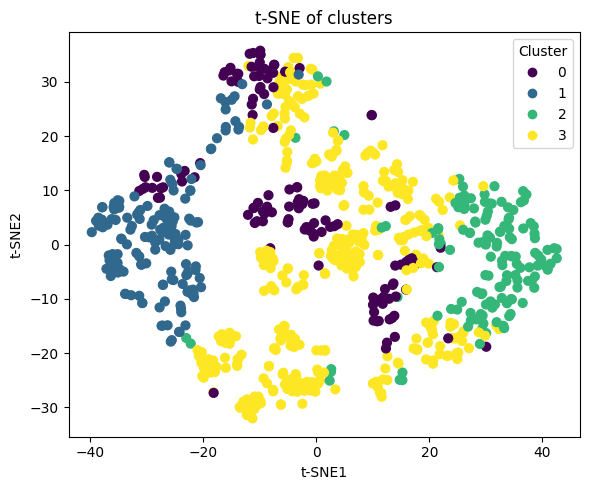

In [260]:
tsne_df = plot_tsne_clusters(X, df_km["Cluster"])

In [262]:
def plot_features_by_cluster(
    df,
    scaler,
    numeric_cols,
    onehot_cols,
    cluster_col="Cluster",
    n_cols=3,
    figsize_per_plot=(5, 4),
    showfliers=False
):
    df_plot = df.copy()


    df_plot[numeric_cols] = scaler.inverse_transform(df_plot[numeric_cols])


    n_num = len(numeric_cols)
    n_rows_num = int(np.ceil(n_num / n_cols))

    fig, axes = plt.subplots(
        n_rows_num, n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows_num)
    )
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.boxplot(
            data=df_plot,
            x=cluster_col,
            y=col,
            ax=axes[i],
            showfliers=showfliers
        )
        axes[i].set_title(col)
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel("Value")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Numeric features by cluster", fontsize=16)
    plt.tight_layout()
    plt.show()


    n_cat = len(onehot_cols)
    n_rows_cat = int(np.ceil(n_cat / n_cols))

    fig, axes = plt.subplots(
        n_rows_cat, n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows_cat)
    )
    axes = np.array(axes).reshape(-1)

    cluster_rates = (
        df_plot.groupby(cluster_col)[onehot_cols]
        .mean()
        .reset_index()
    )

    for i, col in enumerate(onehot_cols):
        sns.barplot(
            data=cluster_rates,
            x=cluster_col,
            y=col,
            ax=axes[i]
        )
        axes[i].set_title(col)
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel("Proportion of 1")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Categorical one-hot features by cluster", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [263]:
numeric_cols = ["Age", "Job", "Credit amount", "Duration", "Saving accounts encoded"]
onehot_cols = [c for c in df_km.columns if c.startswith("Sex_") or c.startswith("Housing_") or c.startswith("Purpose_")]

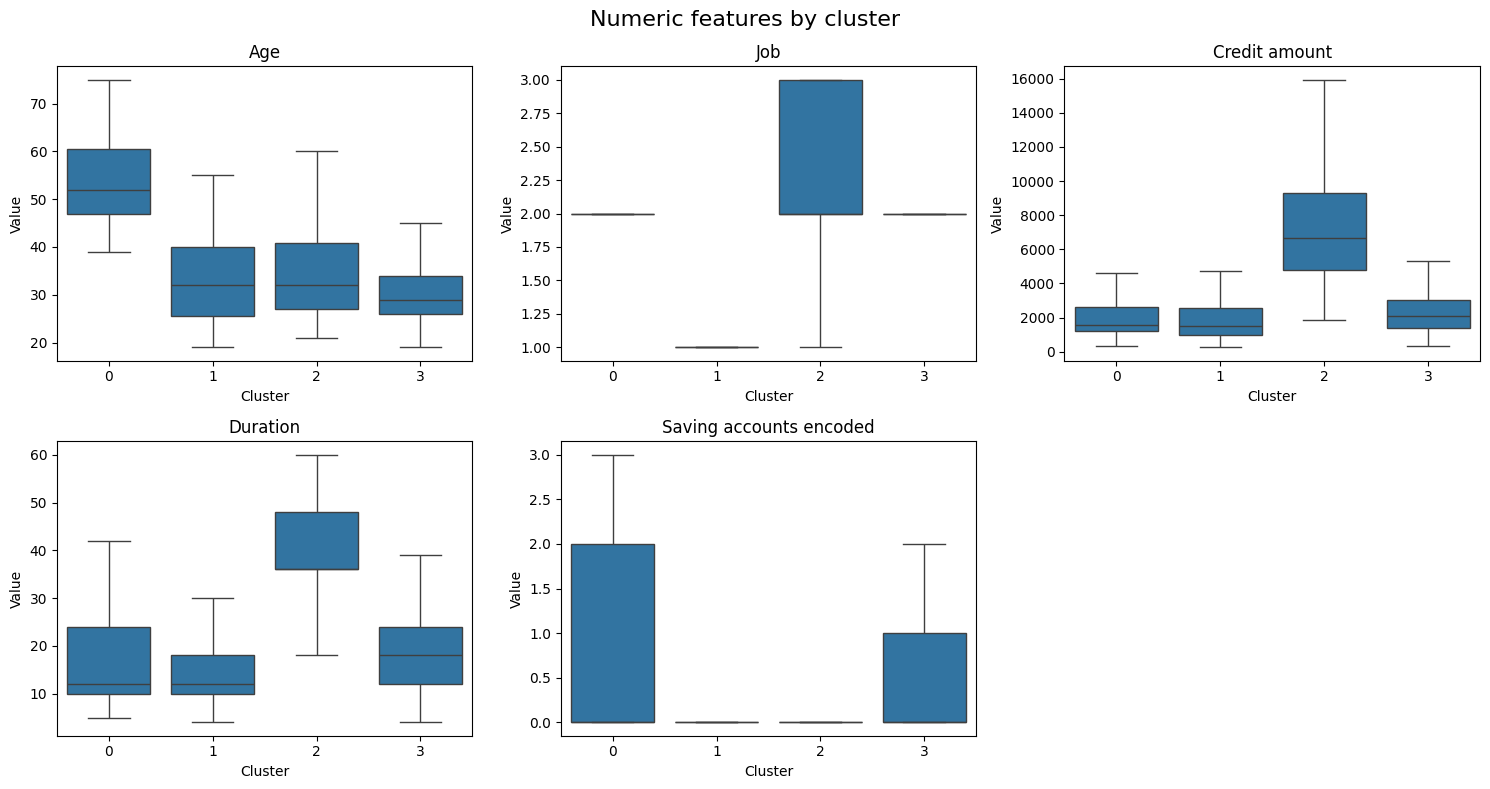

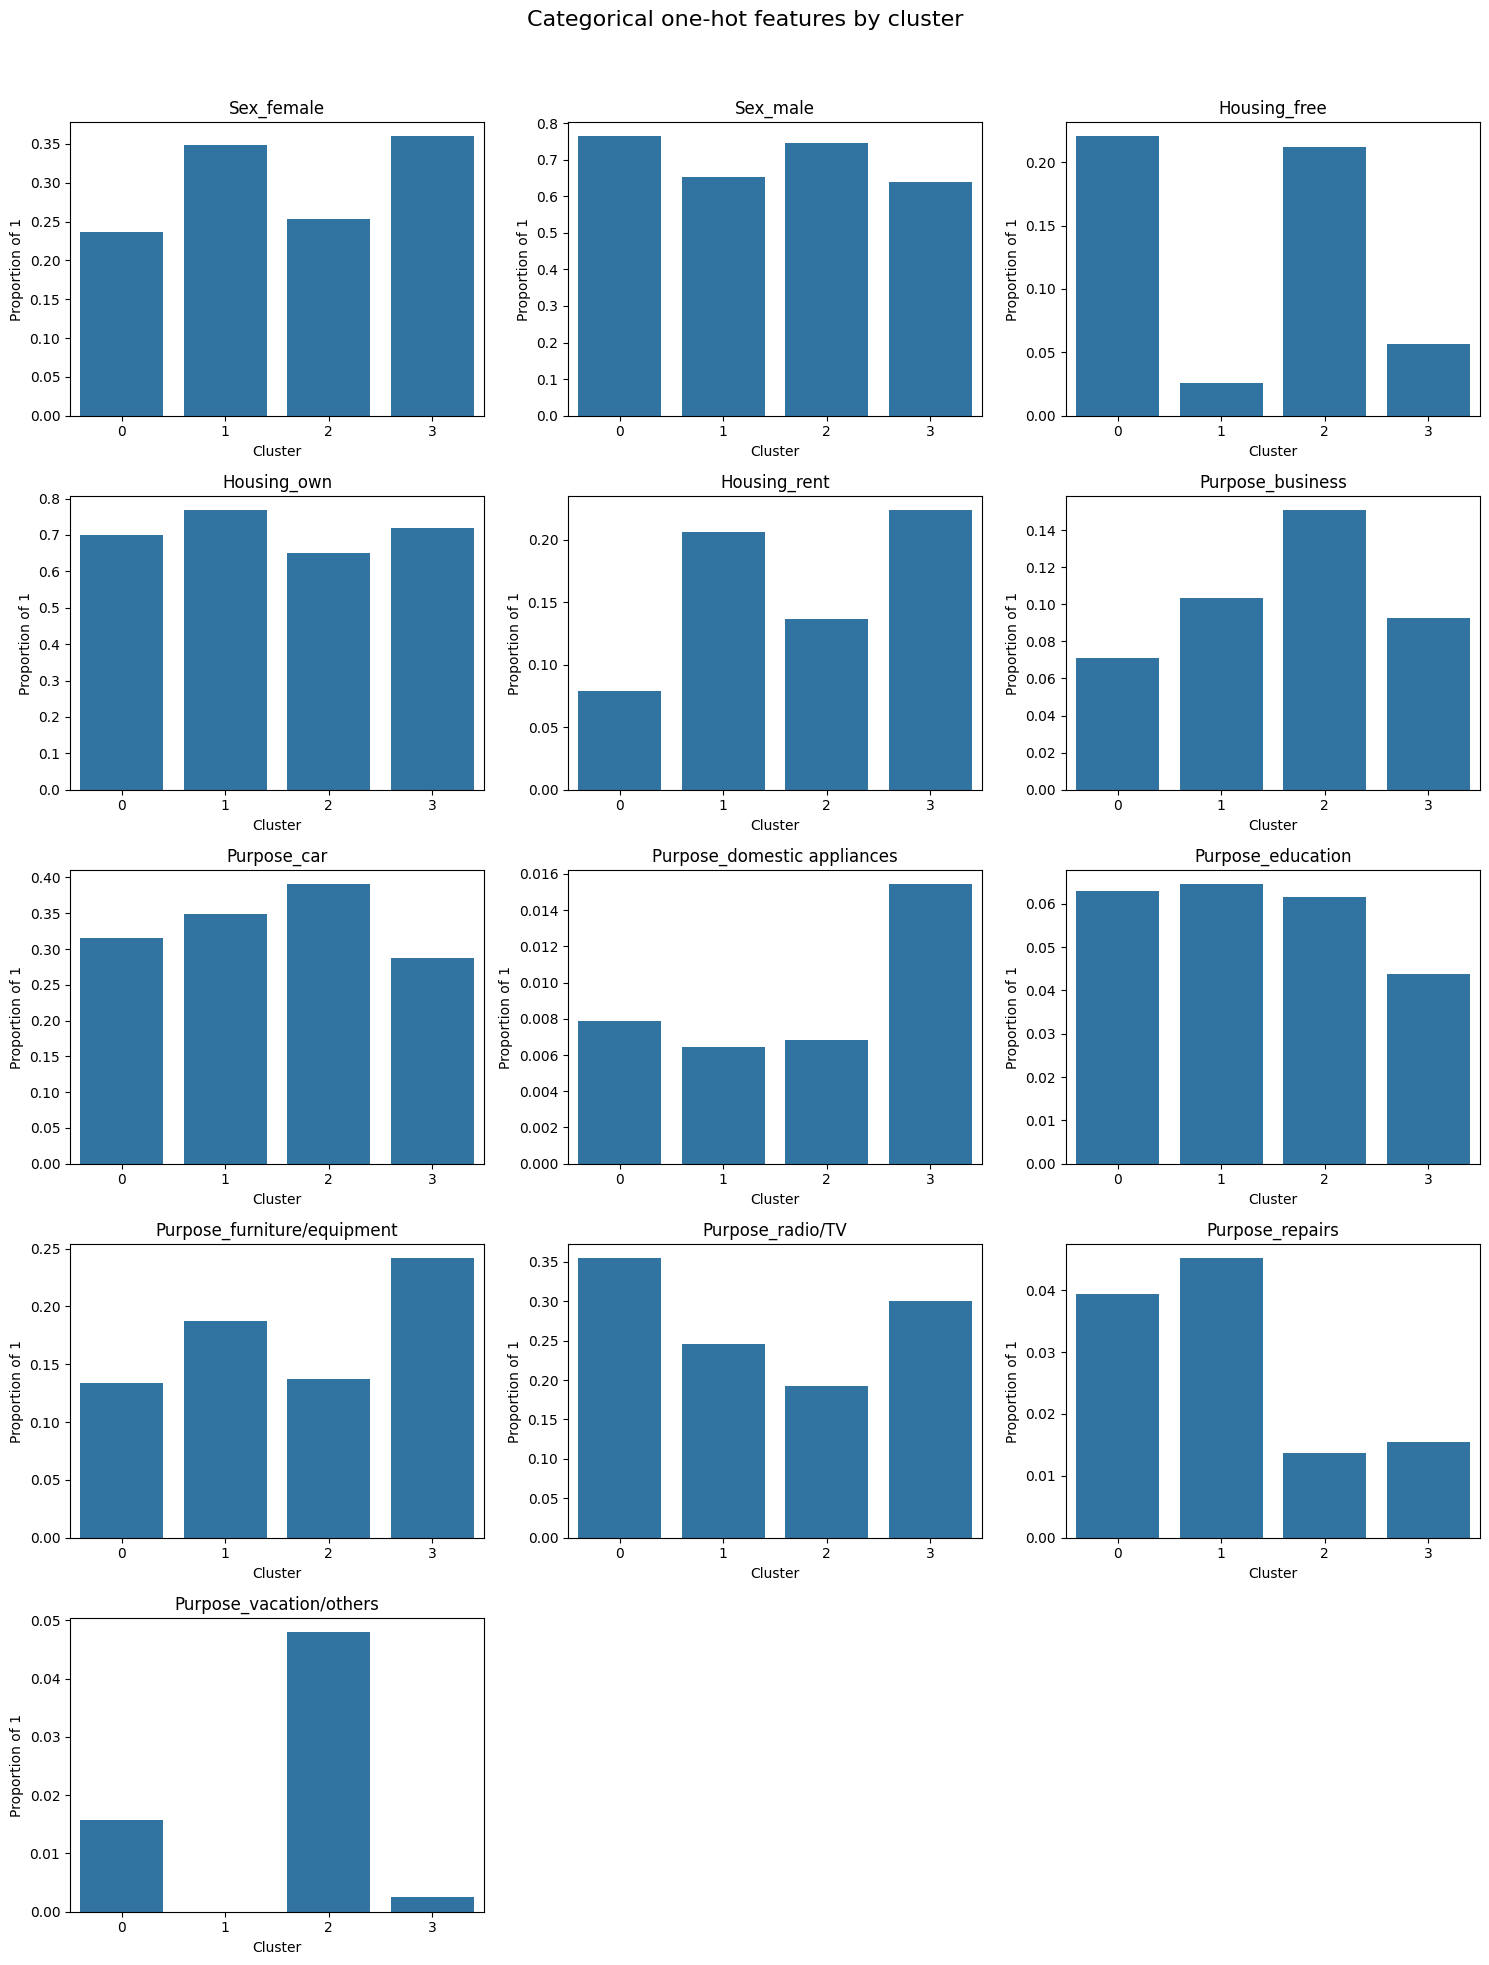

In [264]:
plot_features_by_cluster(
    df=df_km,
    scaler=scaler,
    numeric_cols=numeric_cols,
    onehot_cols=onehot_cols,
    cluster_col="Cluster"
)

### Видно, что и на PCA и на t-SNE хорошо выделяется кластер 2. Клиенты в этом кластере берут наибольшие кредиты и на более долгий срок, при этом обладают высоквалифицированной работой и берут кредит для нужды бизнеса и отпуска

### DBScan

In [265]:
### подбираем epsila
from sklearn.neighbors import NearestNeighbors

def plot_k_distance(X, k=5):

    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs_fit = nbrs.fit(X)

    distances, _ = nbrs_fit.kneighbors(X)

    k_distances = np.sort(distances[:, k-1])

    plt.figure(figsize=(6,4))
    plt.plot(k_distances)
    plt.xlabel("Points")
    plt.ylabel("Distance")
    plt.title("k-distance plot")
    plt.show()

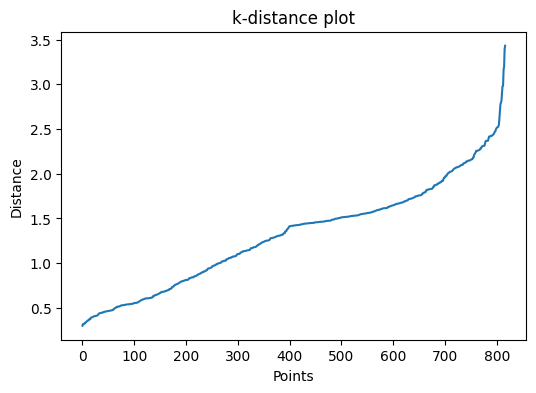

In [266]:
plot_k_distance(X, k=5)

In [267]:
from sklearn.cluster import DBSCAN

def run_dbscan(X, eps=1.5, min_samples=20):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print("Number of clusters:", n_clusters)
    print("Number of noise points:", n_noise)

    return labels

In [268]:
labels = run_dbscan(X)
df_db = X.copy()
df_db["Cluster"] = labels

Number of clusters: 2
Number of noise points: 393


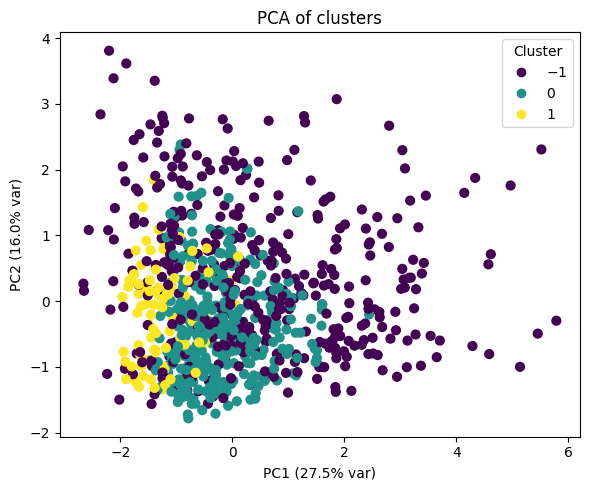

In [270]:
pca_df = plot_pca_clusters(X, df_db["Cluster"])

tsne_df = plot_tsne_clusters(X, df_db["Cluster"])

In [272]:
numeric_cols = ["Age", "Job", "Credit amount", "Duration", "Saving accounts encoded"]
onehot_cols = [c for c in df_db.columns if c.startswith("Sex_") or c.startswith("Housing_") or c.startswith("Purpose_")]

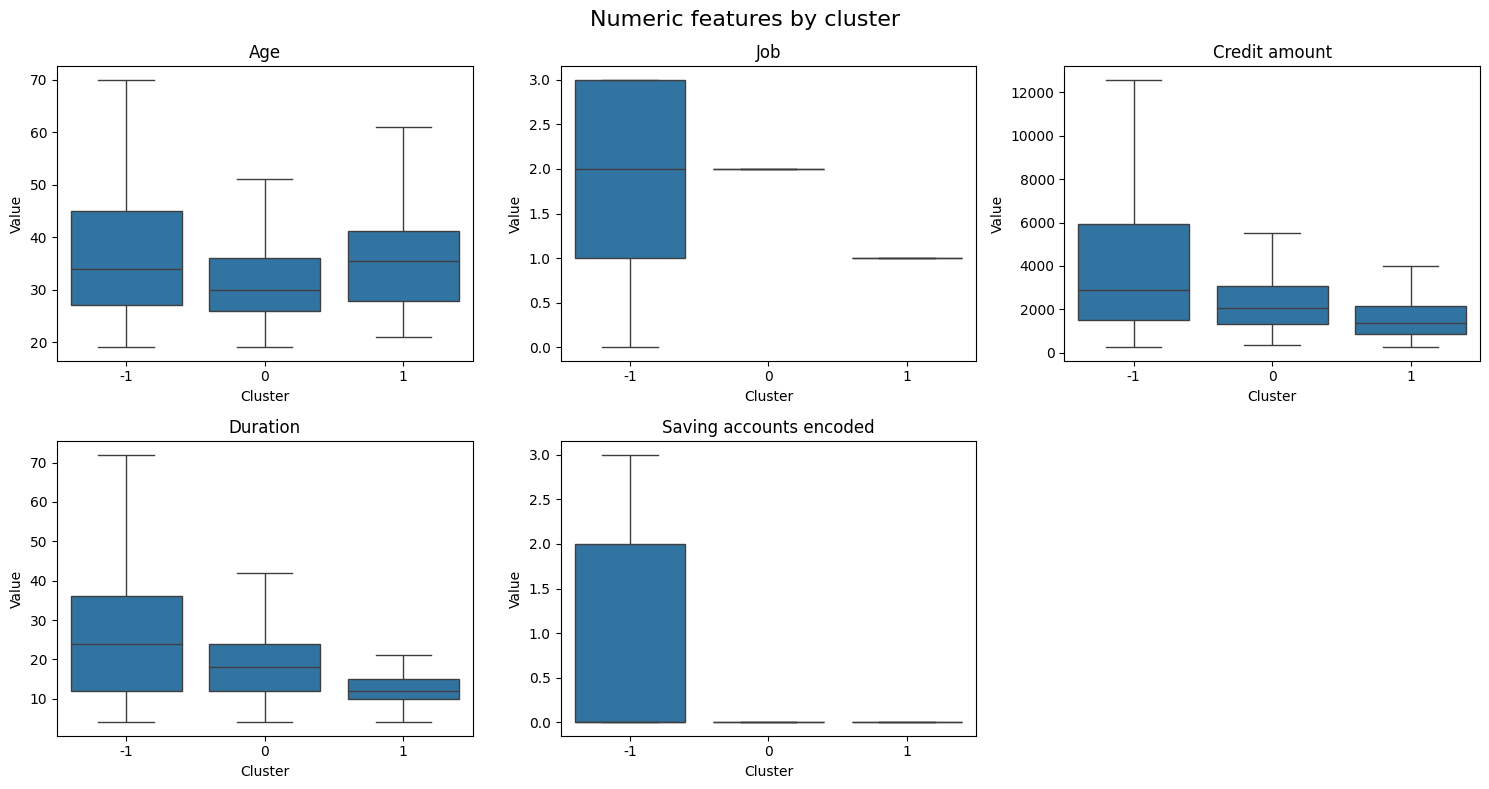

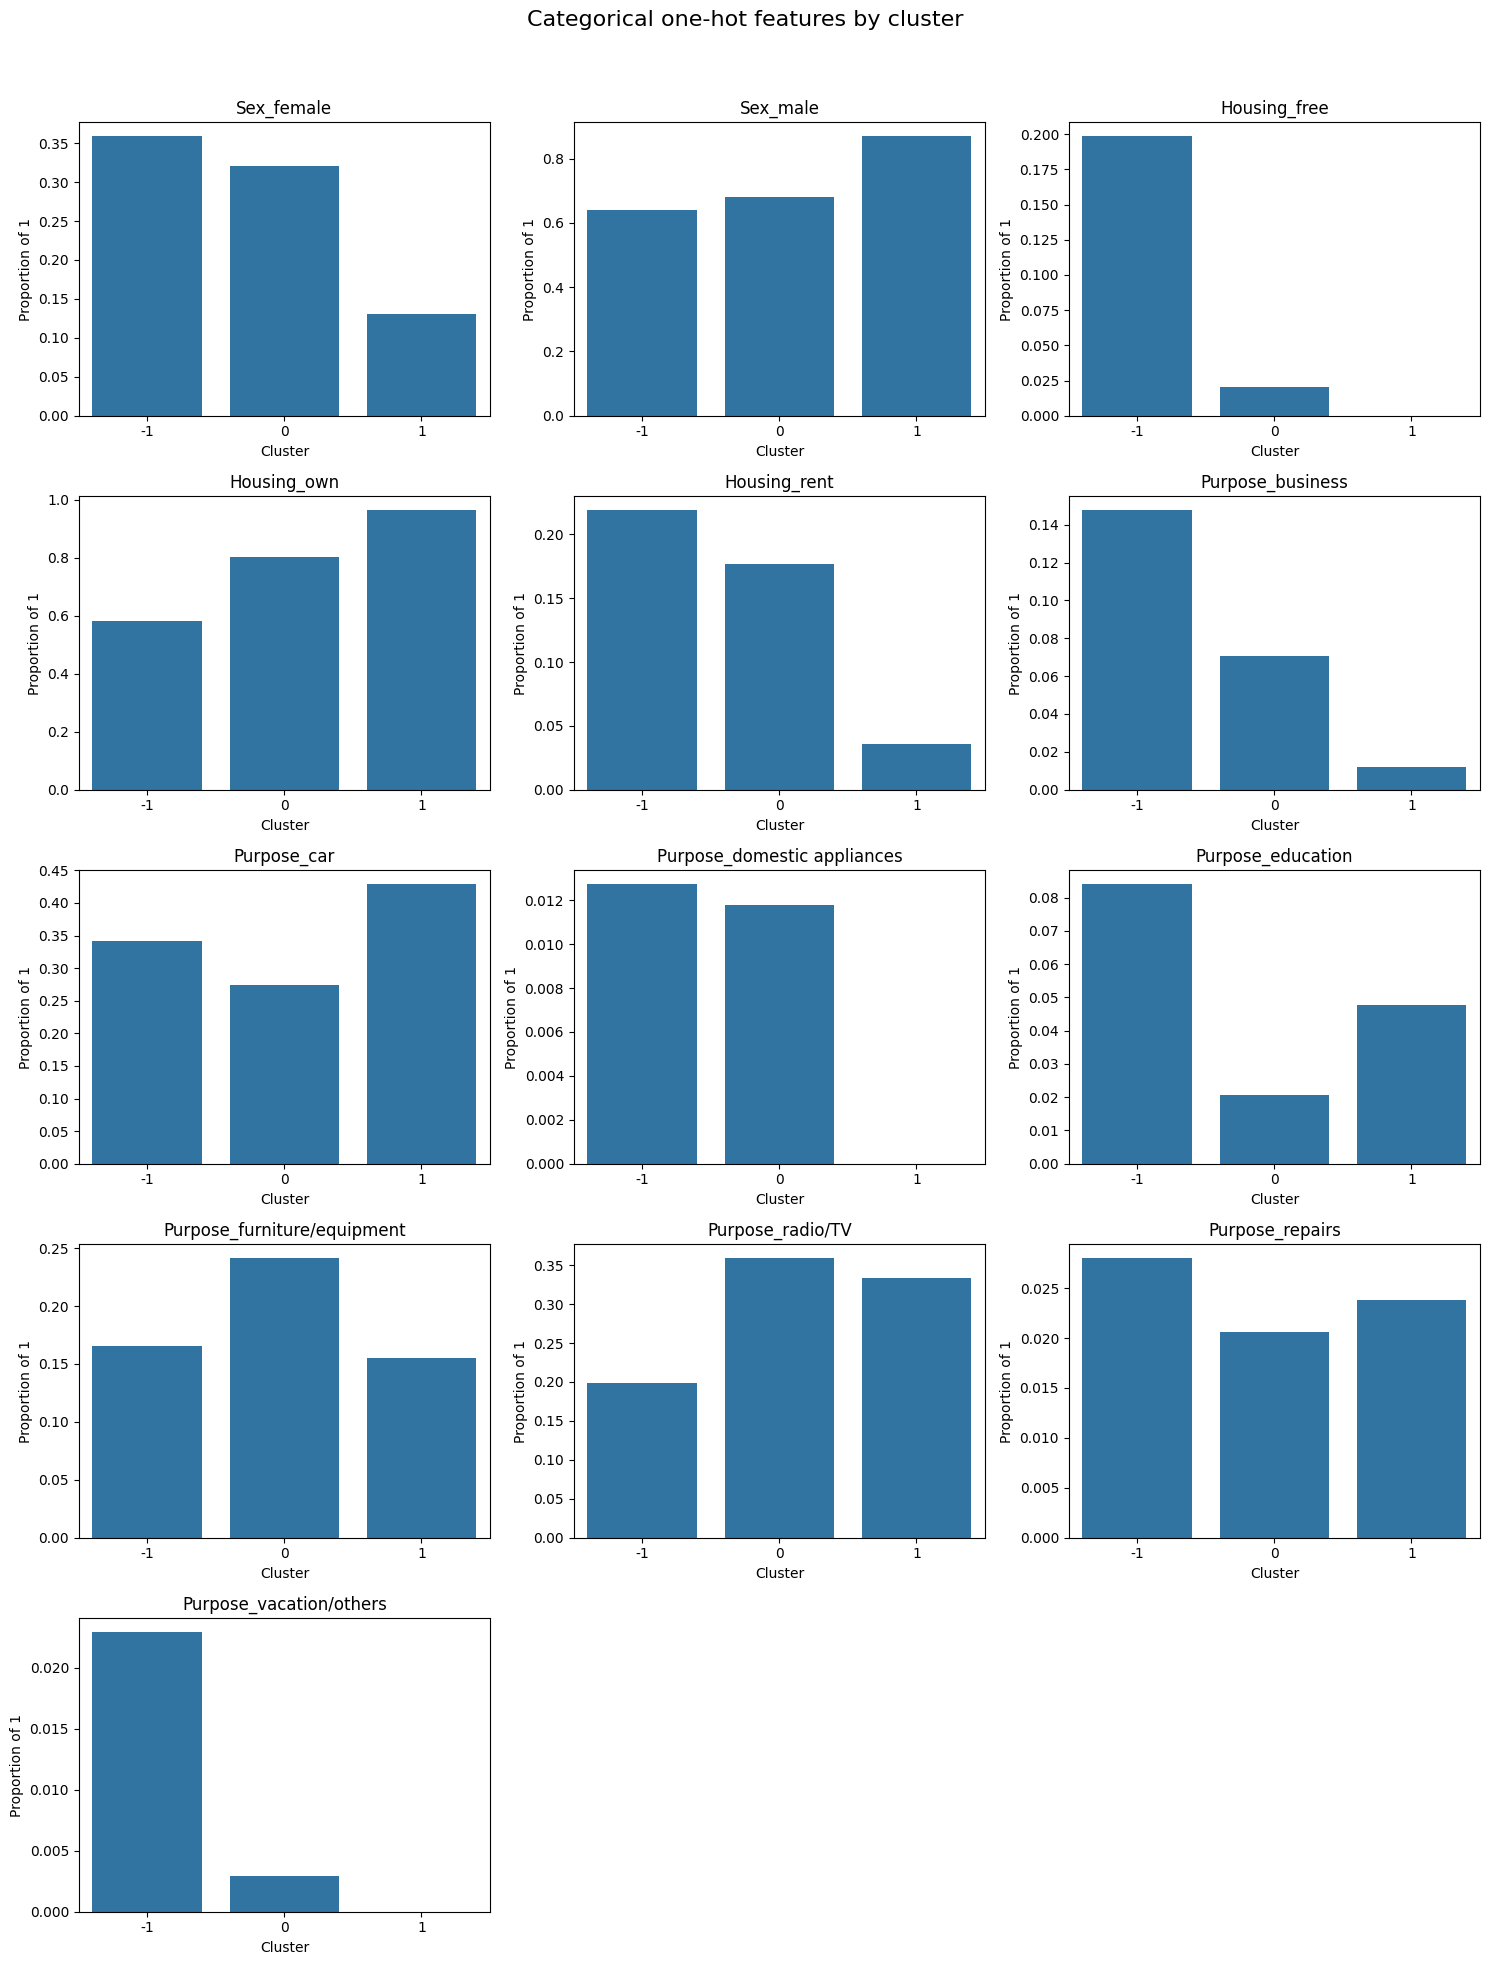

In [273]:
plot_features_by_cluster(
    df=df_db,
    scaler=scaler,
    numeric_cols=numeric_cols,
    onehot_cols=onehot_cols,
    cluster_col="Cluster"
)

### В DBScan кластеры формируются не очень четко, сложно найти закономерности

#### иерархическая кластеризация

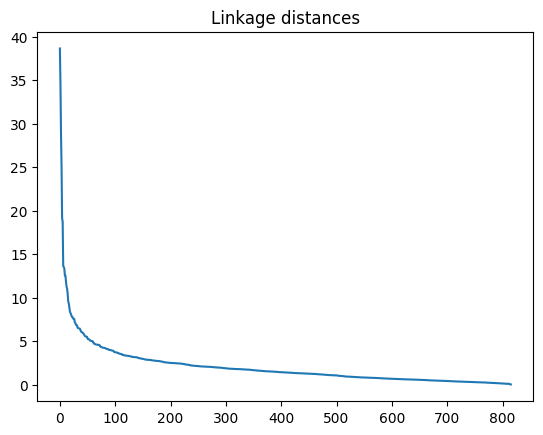

In [274]:
### подбираем число кластеров

from scipy.cluster.hierarchy import linkage

Z = linkage(X, method="ward")

distances = Z[:, 2]

plt.plot(distances[::-1])
plt.title("Linkage distances")
plt.show()

In [275]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def silhouette_hc(X, k_range=range(2, 10)):

    scores = []

    for k in k_range:
        hc = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )

        labels = hc.fit_predict(X)

        score = silhouette_score(X, labels)
        scores.append(score)

    plt.plot(list(k_range), scores, marker="o")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.show()

    return scores

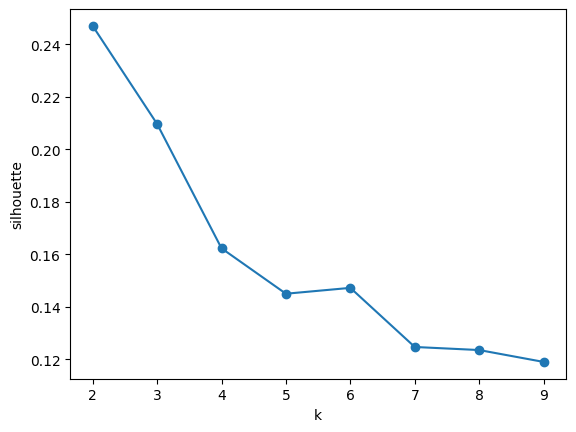

[np.float64(0.24703275035403602),
 np.float64(0.20969237541366895),
 np.float64(0.16232998905700238),
 np.float64(0.1450352954388222),
 np.float64(0.1472682720335919),
 np.float64(0.1247553262733535),
 np.float64(0.12358501239394364),
 np.float64(0.11906224803192612)]

In [276]:
silhouette_hc(X, range(2, 10))

In [277]:
### на основе двух методов выберем число кластеров = 3

def run_hierarchical_clustering(X, n_clusters=3, metric="euclidean", linkage="ward"):
    hc = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric=metric,
        linkage=linkage
    )

    labels = hc.fit_predict(X)

    print("Number of clusters:", len(set(labels)))
    print(pd.Series(labels).value_counts().sort_index())

    return labels

In [278]:
labels = run_hierarchical_clustering(X)
df_hc = X.copy()
df_hc["Cluster"] = labels

Number of clusters: 3
0    618
1     94
2    105
Name: count, dtype: int64


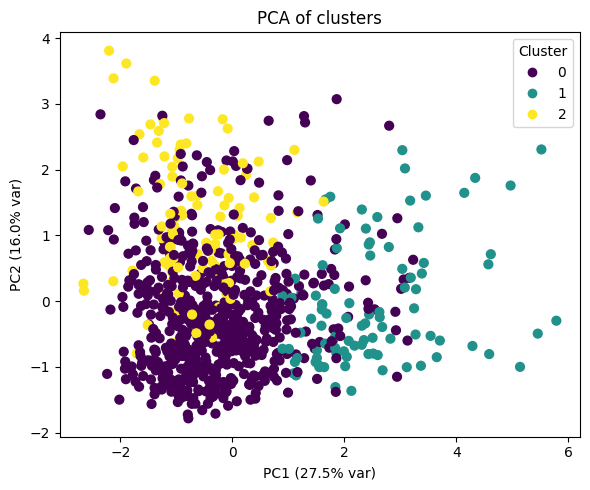

In [279]:
pca_df = plot_pca_clusters(X, df_hc["Cluster"])

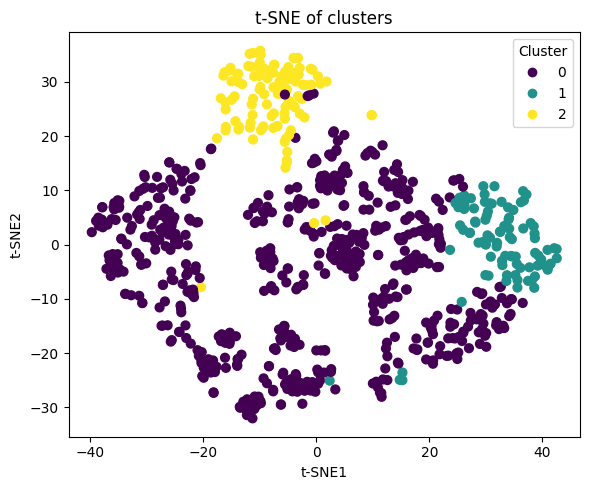

In [280]:
tsne_df = plot_tsne_clusters(X, df_hc["Cluster"])

In [281]:
numeric_cols = ["Age", "Job", "Credit amount", "Duration", "Saving accounts encoded"]
onehot_cols = [c for c in df_hc.columns if c.startswith("Sex_") or c.startswith("Housing_") or c.startswith("Purpose_")]

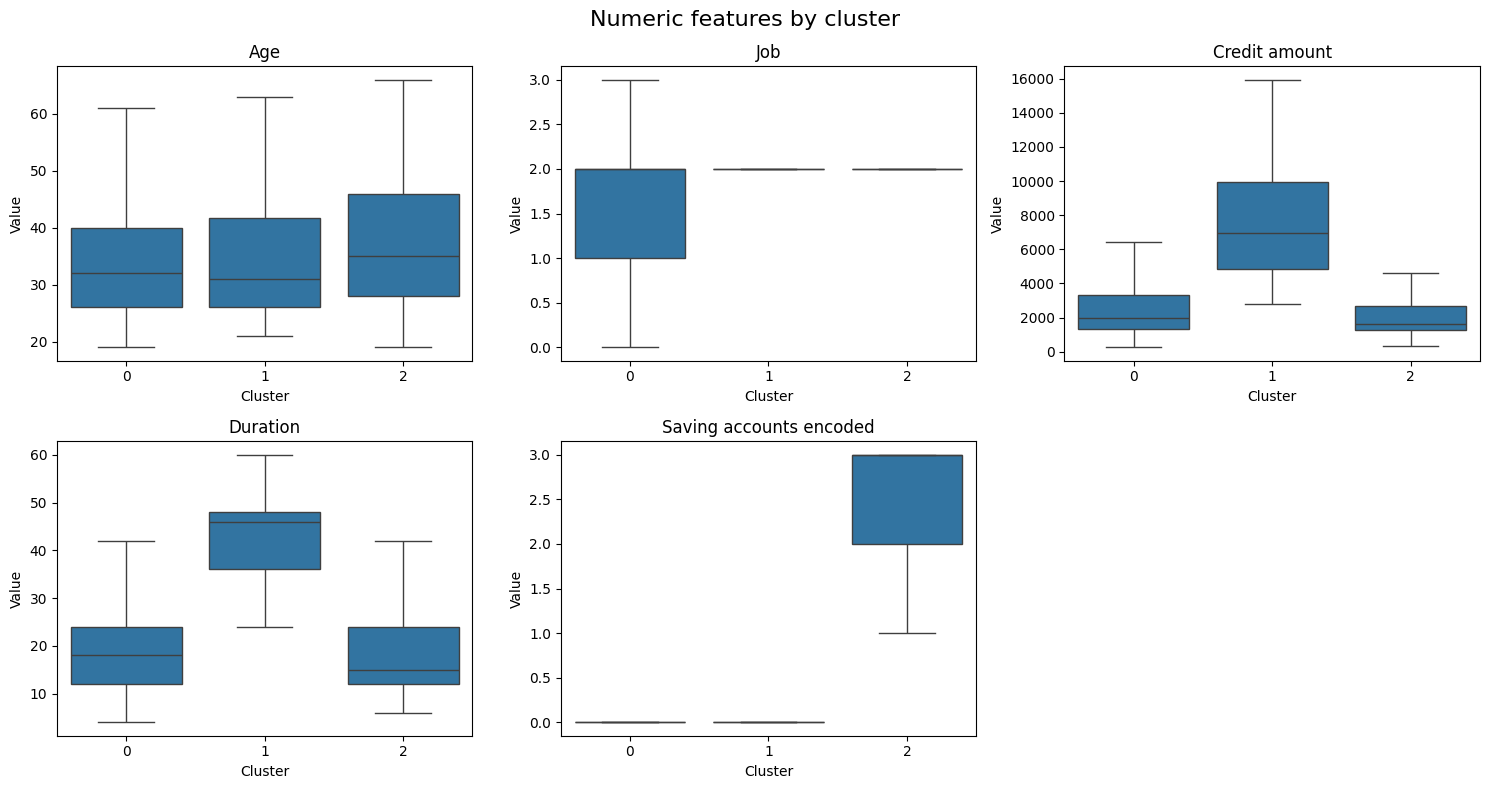

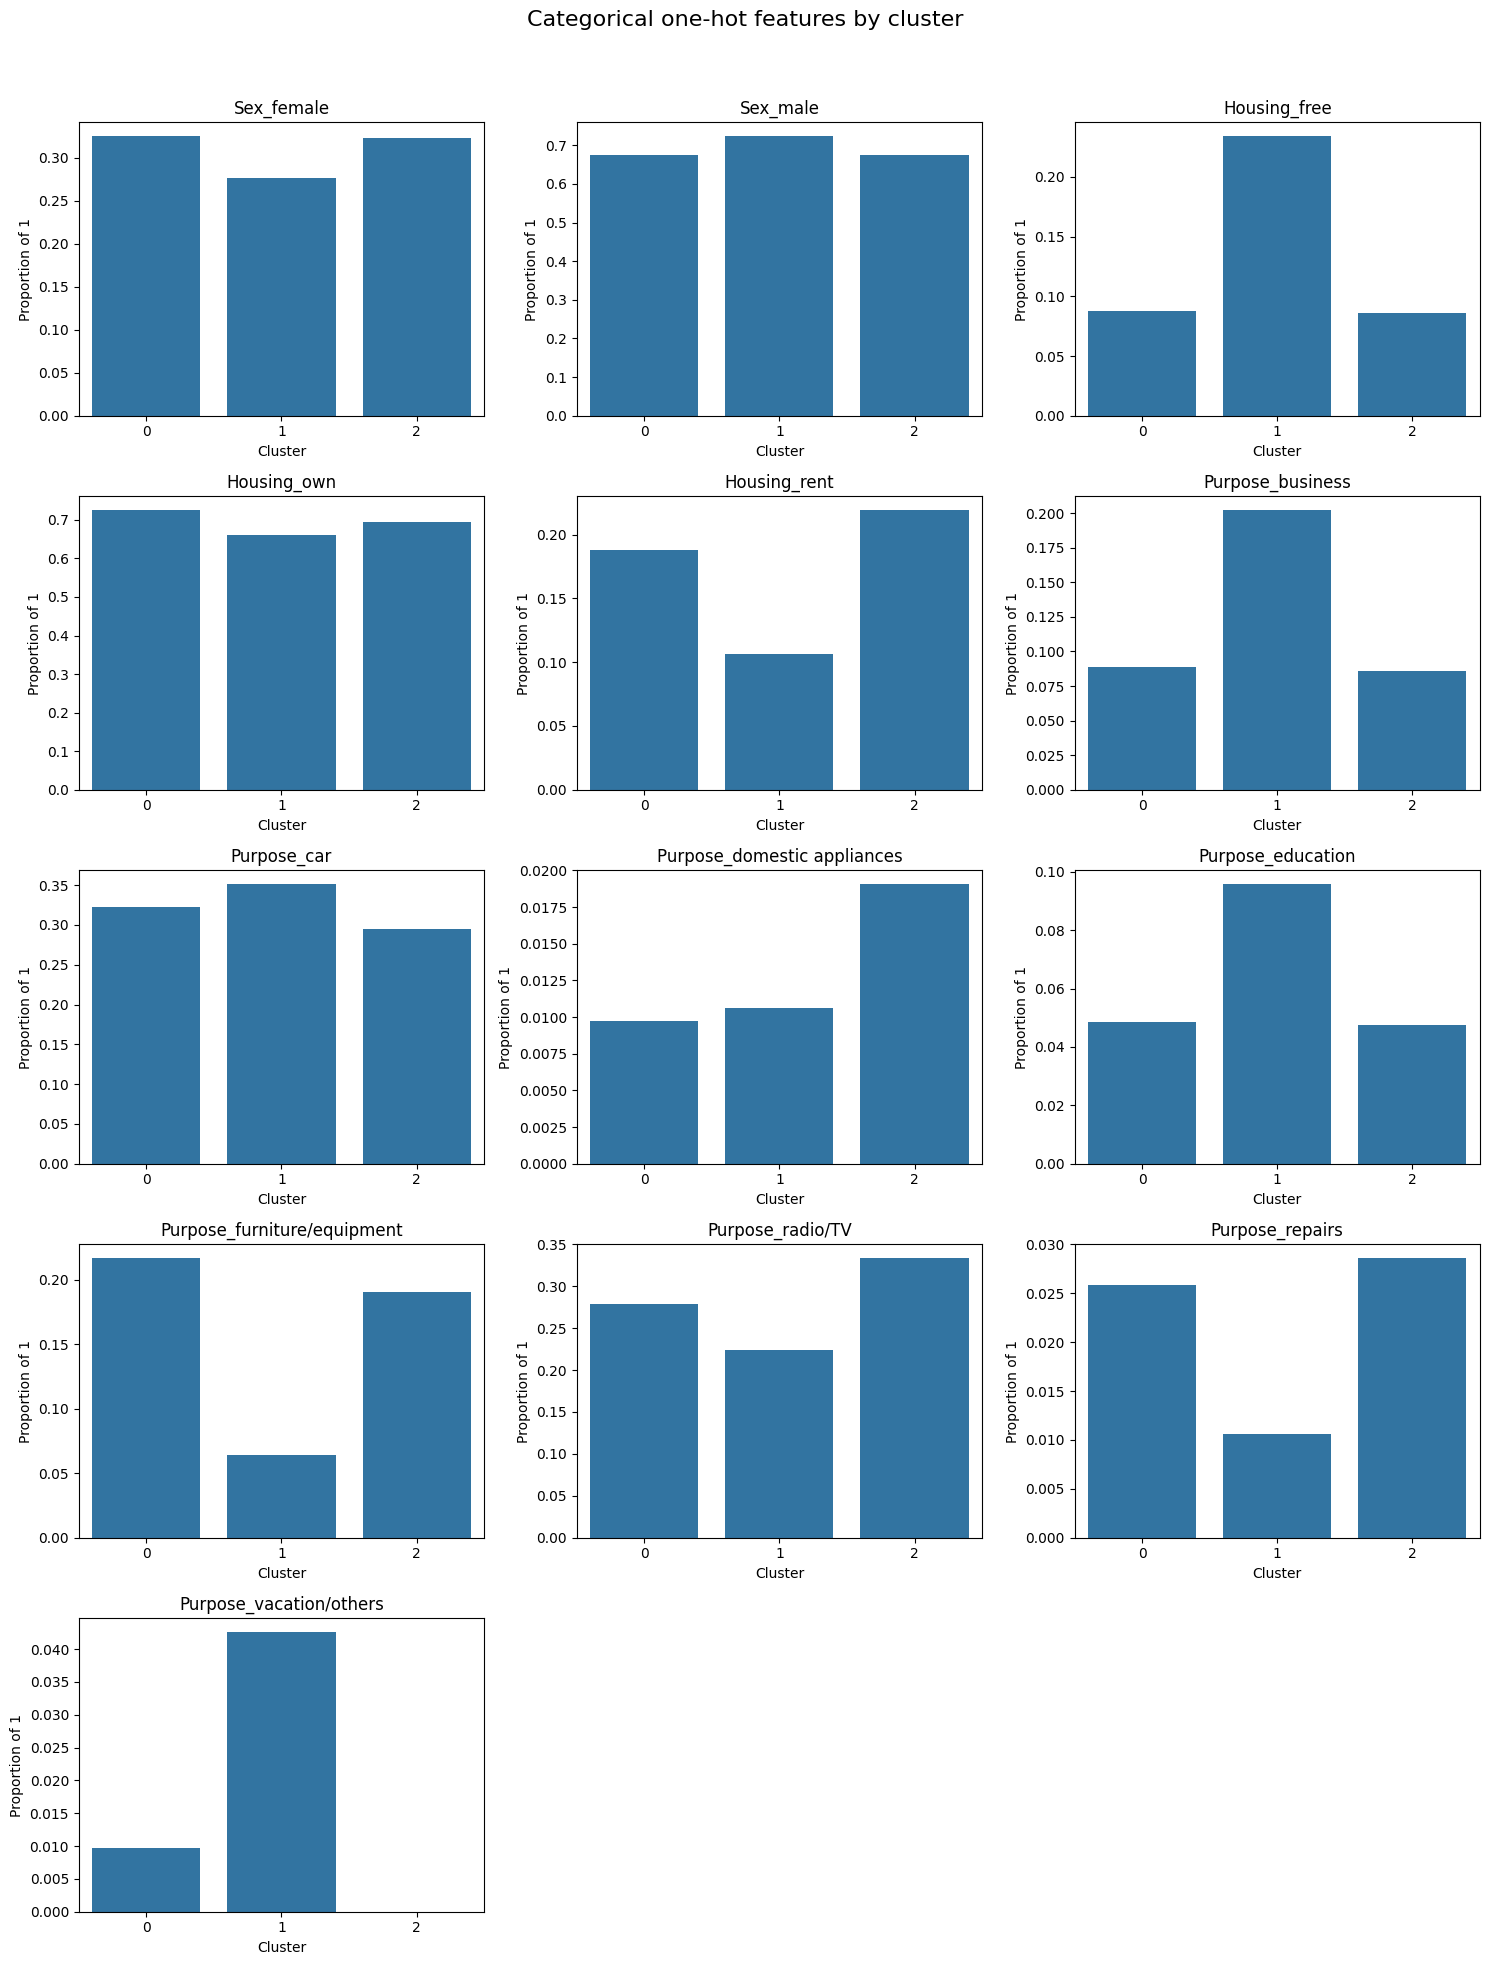

In [282]:
plot_features_by_cluster(
    df=df_hc,
    scaler=scaler,
    numeric_cols=numeric_cols,
    onehot_cols=onehot_cols,
    cluster_col="Cluster"
)

### В иерархической кластеризации тоже есть ярко выделяющийся кластер - 1. Клиенты в этом кластере также берут самые большие кредиты и на более долгий срок, для целей бизнеса, образования и отпуска, что похоже на самый яркий кластер в k-means. 